# Notebook 12: Wasting and Anemia Prediction Models

This notebook extends the stunting modeling framework from notebook 10 to the two 
remaining nutrition outcomes: wasting and anemia. The three outcomes together 
represent the full multi-outcome architecture of this project, with each outcome 
capturing a distinct dimension of child undernutrition as defined by the UNICEF 
Conceptual Framework.

Wasting, defined as weight-for-height z-score below -2, reflects acute undernutrition 
from recent food insecurity or illness. It has a prevalence of 2.1% in the 2024 MDHS 
national sample, producing only 110 positive cases. This extreme class imbalance 
requires different modeling choices than stunting. SMOTE oversampling is applied to 
the training folds and scale_pos_weight is set aggressively. Precision-recall AUC 
replaces ROC-AUC as the primary metric because ROC-AUC is optimistic under severe 
imbalance.

Anemia, defined as hemoglobin below the age-adjusted threshold using the hw57 
categorical classification, has a prevalence of 48.9% among tested children. Only 
3,839 of the 5,122 national sample children have hemoglobin measurements because 
the 2024 MDHS tested children aged 6 months and above. The untested children are 
significantly younger with a mean age of 15.7 months versus 32.3 months for tested 
children. This is not random missingness but a systematic age-related selection 
effect from the survey design. The anemia model is therefore restricted to the 
3,839 tested children and results are interpreted as applying to children aged 
6 months and above.

Both models use the same feature set and DHS sampling weights as the stunting 
model to maintain methodological consistency across the three outcomes.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib

PROJECT_ROOT   = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS         = PROJECT_ROOT / "outputs" / "models"
FIGURES        = PROJECT_ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df    = pd.read_parquet(DATA_PROCESSED / "model_dataset_national.parquet")
df_kr = pd.read_parquet(DATA_INTERIM / "kr_clean.parquet")

print("National dataset:", df.shape)

National dataset: (5122, 48)


## Adding correct sampling weights and district context

The same weight correction and district context engineering applied in notebook 10 
is repeated here to ensure all three outcome models are trained on an identical 
methodological foundation.

In [7]:
# correct sampling weight
kr_weights = df_kr[["v001", "v002", "bidx", "hw70", "v005"]].copy()
kr_weights = kr_weights.rename(columns={
    "v001": "id_cluster", "v002": "id_household",
    "bidx": "id_child_index", "hw70": "haz_score",
    "v005": "sample_weight"
})
kr_weights["sample_weight"] = kr_weights["sample_weight"] / 1_000_000

df = df.merge(
    kr_weights,
    on=["id_cluster", "id_household", "id_child_index", "haz_score"],
    how="left"
)
df = df.drop_duplicates(
    subset=["id_cluster", "id_household", "id_child_index", "haz_score"]
)

# district contextual features
district_stats = (df.groupby("str_district")
                  .agg(
                      district_stunting_rate   = ("outcome_stunted", "mean"),
                      district_mean_age        = ("imm_child_age_months", "mean"),
                      district_mean_wealth     = ("enc_wealth_index", "mean"),
                      district_mean_mat_height = ("und_maternal_height_cm", "mean")
                  ).reset_index())

df = df.merge(district_stats, on="str_district", how="left")

print("Shape after weight and district merge:", df.shape)
print("Weight stats:")
print(df["sample_weight"].describe().round(4))

Shape after weight and district merge: (5122, 53)
Weight stats:
count    5122.0000
mean        1.0169
std         0.6647
min         0.0133
25%         0.5282
50%         0.8605
75%         1.4002
max         3.7057
Name: sample_weight, dtype: float64


## Defining feature sets and preparing outcome datasets

The feature set is identical to the stunting model. Two separate modeling datasets 
are created: one for wasting using all 5,122 national sample records, and one for 
anemia restricted to the 3,839 children with hemoglobin measurements.

For wasting, records with zero sampling weight are excluded. For anemia, both 
zero-weight and untested records are excluded.

In [8]:
FEATURES = [
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height"
]

# wasting dataset
df_wasting = df[df["sample_weight"] > 0].copy()
X_w = df_wasting[FEATURES]
y_w = df_wasting["outcome_wasting"].astype(int)
w_w = df_wasting["sample_weight"]

# anemia dataset: tested children only
df_anemia = df[
    (df["sample_weight"] > 0) &
    (df["outcome_anemia"].notna())
].copy()
X_a = df_anemia[FEATURES]
y_a = df_anemia["outcome_anemia"].astype(int)
w_a = df_anemia["sample_weight"]

print("=== Wasting dataset ===")
print(f"Records: {len(df_wasting)}")
print(f"Positive cases: {y_w.sum()} ({y_w.mean():.3f})")
print(f"Class ratio: {(y_w==0).sum()}:{(y_w==1).sum()}")

print("\n=== Anemia dataset ===")
print(f"Records: {len(df_anemia)}")
print(f"Positive cases: {y_a.sum()} ({y_a.mean():.3f})")
print(f"Class ratio: {(y_a==0).sum()}:{(y_a==1).sum()}")

print(f"\nMissing in wasting features: {X_w.isnull().sum().sum()}")
print(f"Missing in anemia features: {X_a.isnull().sum().sum()}")

=== Wasting dataset ===
Records: 5122
Positive cases: 110 (0.021)
Class ratio: 5012:110

=== Anemia dataset ===
Records: 3839
Positive cases: 1877 (0.489)
Class ratio: 1962:1877

Missing in wasting features: 0
Missing in anemia features: 0


## Training wasting models

Wasting has only 110 positive cases in 5,122 records, a class ratio of 46:1. 
Standard model training will collapse the minority class. Three strategies are 
combined to address this.

SMOTE oversampling is applied within each training fold to synthetically generate 
additional wasting cases. It is applied only to the training fold, never to the 
test fold, to avoid data leakage.

scale_pos_weight for XGBoost and LightGBM is set to the exact class ratio of 46. 
class_weight balanced is used for logistic regression and random forest.

Precision-recall AUC is the primary metric. With 110 positive cases out of 5,122, 
a model that predicts everyone as not wasted gets ROC-AUC of around 0.85 by 
exploiting the class imbalance. Precision-recall AUC is immune to this and gives 
an honest picture of model performance on the minority class.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=5)

pos_weight_w = (y_w == 0).sum() / (y_w == 1).sum()
print(f"Wasting scale_pos_weight: {pos_weight_w:.1f}")

def evaluate_imbalanced(model, X, y, w, cv, smote, name):
    metrics = {
        "pr_auc": [], "roc_auc": [], "f1": [],
        "recall": [], "precision": []
    }
    pr_curves  = []
    roc_curves = []

    for train_idx, test_idx in cv.split(X, y):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]
        w_train = w.iloc[train_idx]

        # apply SMOTE only to training fold
        X_res, y_res = smote.fit_resample(X_train, y_train)
        w_res = np.ones(len(X_res))
        w_res[:len(w_train)] = w_train.values

        model.fit(X_res, y_res, sample_weight=w_res)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        metrics["pr_auc"].append(average_precision_score(y_test, y_proba))
        metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
        metrics["f1"].append(f1_score(y_test, y_pred, zero_division=0))
        metrics["recall"].append(recall_score(y_test, y_pred, zero_division=0))
        metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))

        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        pr_curves.append((prec, rec))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves.append((fpr, tpr))

    summary = {k: np.mean(v) for k, v in metrics.items()}
    summary["model"] = name
    return summary, pr_curves, roc_curves

class WeightedPipeline:
    def __init__(self, pipe):
        self.pipe = pipe
    def fit(self, X, y, sample_weight=None):
        self.pipe.fit(X, y, clf__sample_weight=sample_weight)
        return self
    def predict(self, X):
        return self.pipe.predict(X)
    def predict_proba(self, X):
        return self.pipe.predict_proba(X)

lr_w  = WeightedPipeline(Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000, class_weight="balanced",
        solver="liblinear", random_state=42))
]))
rf_w  = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1
)
xgb_w = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=pos_weight_w,
    random_state=42, eval_metric="aucpr", verbosity=0
)
lgb_w = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=pos_weight_w,
    random_state=42, verbosity=-1
)

models_w = [
    (lr_w,  "Logistic Regression"),
    (rf_w,  "Random Forest"),
    (xgb_w, "XGBoost"),
    (lgb_w, "LightGBM")
]

print("\nTraining wasting models with SMOTE and 5-fold CV...\n")

results_w  = []
pr_data_w  = {}
roc_data_w = {}

for model, name in models_w:
    print(f"Training {name}...")
    r, pr, roc = evaluate_imbalanced(model, X_w, y_w, w_w, cv, smote, name)
    results_w.append(r)
    pr_data_w[name]  = pr
    roc_data_w[name] = roc
    print(f"  PR-AUC: {r['pr_auc']:.4f} | ROC-AUC: {r['roc_auc']:.4f} | "
          f"F1: {r['f1']:.4f} | Recall: {r['recall']:.4f} | "
          f"Precision: {r['precision']:.4f}")

results_w_df = pd.DataFrame(results_w).set_index("model")
print("\n=== Wasting Model Comparison ===")
print(results_w_df.round(4))

Wasting scale_pos_weight: 45.6

Training wasting models with SMOTE and 5-fold CV...

Training Logistic Regression...
  PR-AUC: 0.0499 | ROC-AUC: 0.5630 | F1: 0.0506 | Recall: 0.3091 | Precision: 0.0276
Training Random Forest...
  PR-AUC: 0.0575 | ROC-AUC: 0.6089 | F1: 0.0462 | Recall: 0.0273 | Precision: 0.1567
Training XGBoost...
  PR-AUC: 0.0654 | ROC-AUC: 0.6183 | F1: 0.0759 | Recall: 0.3455 | Precision: 0.0426
Training LightGBM...
  PR-AUC: 0.0725 | ROC-AUC: 0.6146 | F1: 0.0716 | Recall: 0.3364 | Precision: 0.0401

=== Wasting Model Comparison ===
                     pr_auc  roc_auc      f1  recall  precision
model                                                          
Logistic Regression  0.0499   0.5630  0.0506  0.3091     0.0276
Random Forest        0.0575   0.6089  0.0462  0.0273     0.1567
XGBoost              0.0654   0.6183  0.0759  0.3455     0.0426
LightGBM             0.0725   0.6146  0.0716  0.3364     0.0401


## Training anemia models

Anemia is near-balanced at 48.9% prevalence among tested children. Standard 
training without oversampling is appropriate here. ROC-AUC is the primary metric 
alongside F1. The anemia model uses the same four algorithms as stunting and wasting 
for consistency in the comparative analysis across outcomes.

The anemia pathways differ from stunting and wasting. Malaria exposure, iron 
deficiency, and inflammatory burden drive anemia independently of the growth 
faltering pathways. We therefore expect a different feature importance profile 
from the stunting model, with region and district playing a larger role given 
the geographic concentration of malaria risk in Malawi's Southern and lakeshore 
districts.

In [10]:
pos_weight_a = (y_a == 0).sum() / (y_a == 1).sum()
print(f"Anemia scale_pos_weight: {pos_weight_a:.2f}")

def evaluate_standard(model, X, y, w, cv, name):
    metrics = {
        "roc_auc": [], "f1": [], "recall": [], "precision": []
    }
    pr_curves  = []
    roc_curves = []

    for train_idx, test_idx in cv.split(X, y):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]
        w_train = w.iloc[train_idx]

        model.fit(X_train, y_train, sample_weight=w_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
        metrics["f1"].append(f1_score(y_test, y_pred))
        metrics["recall"].append(recall_score(y_test, y_pred))
        metrics["precision"].append(precision_score(y_test, y_pred))

        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        pr_curves.append((prec, rec))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves.append((fpr, tpr))

    summary = {k: np.mean(v) for k, v in metrics.items()}
    summary["model"] = name
    return summary, pr_curves, roc_curves

lr_a  = WeightedPipeline(Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000, class_weight="balanced",
        solver="liblinear", random_state=42))
]))
rf_a  = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
xgb_a = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=pos_weight_a,
    random_state=42, eval_metric="logloss", verbosity=0
)
lgb_a = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    class_weight="balanced", random_state=42, verbosity=-1
)

models_a = [
    (lr_a,  "Logistic Regression"),
    (rf_a,  "Random Forest"),
    (xgb_a, "XGBoost"),
    (lgb_a, "LightGBM")
]

print("\nTraining anemia models with 5-fold CV...\n")

results_a  = []
pr_data_a  = {}
roc_data_a = {}

for model, name in models_a:
    print(f"Training {name}...")
    r, pr, roc = evaluate_standard(model, X_a, y_a, w_a, cv, name)
    results_a.append(r)
    pr_data_a[name]  = pr
    roc_data_a[name] = roc
    print(f"  ROC-AUC: {r['roc_auc']:.4f} | F1: {r['f1']:.4f} | "
          f"Recall: {r['recall']:.4f} | Precision: {r['precision']:.4f}")

results_a_df = pd.DataFrame(results_a).set_index("model")
print("\n=== Anemia Model Comparison ===")
print(results_a_df.round(4))

Anemia scale_pos_weight: 1.05

Training anemia models with 5-fold CV...

Training Logistic Regression...
  ROC-AUC: 0.6738 | F1: 0.6089 | Recall: 0.5972 | Precision: 0.6213
Training Random Forest...
  ROC-AUC: 0.6799 | F1: 0.6090 | Recall: 0.5796 | Precision: 0.6416
Training XGBoost...
  ROC-AUC: 0.6561 | F1: 0.6028 | Recall: 0.5860 | Precision: 0.6210
Training LightGBM...
  ROC-AUC: 0.6517 | F1: 0.5895 | Recall: 0.5722 | Precision: 0.6081

=== Anemia Model Comparison ===
                     roc_auc      f1  recall  precision
model                                                  
Logistic Regression   0.6738  0.6089  0.5972     0.6213
Random Forest         0.6799  0.6090  0.5796     0.6416
XGBoost               0.6561  0.6028  0.5860     0.6210
LightGBM              0.6517  0.5895  0.5722     0.6081


## Visualising model performance across all three outcomes

Four charts compare model performance across wasting and anemia, with stunting 
results from notebook 10 included for reference. This is the first time all three 
outcomes appear together and it tells the story of how predictability varies across 
the three dimensions of child undernutrition.

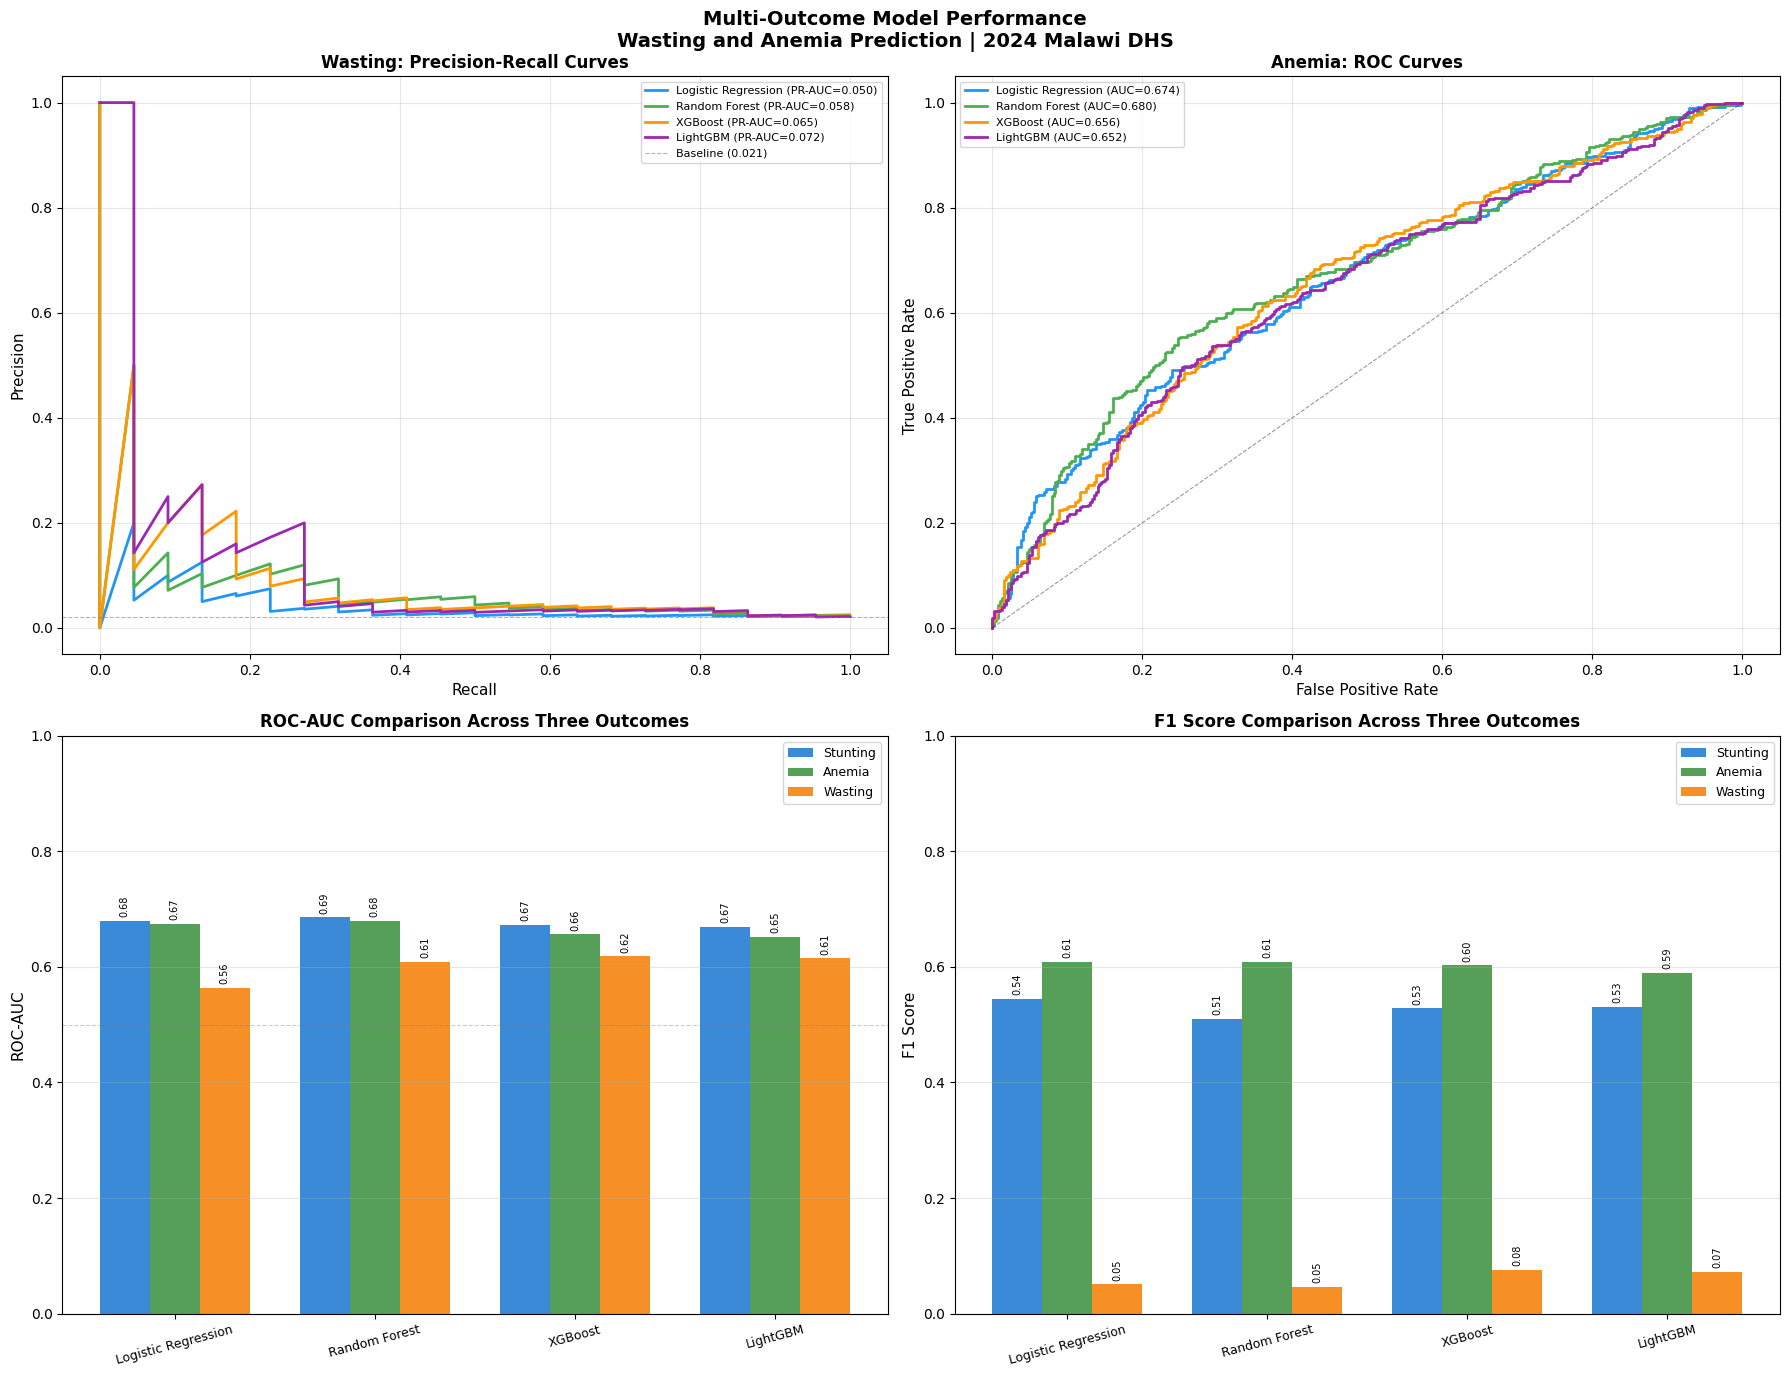

Saved: multi_outcome_performance.png


In [11]:
COLORS = {
    "Logistic Regression": "#2196F3",
    "Random Forest"      : "#4CAF50",
    "XGBoost"            : "#FF9800",
    "LightGBM"           : "#9C27B0"
}

stunting_roc = {
    "Logistic Regression": 0.6798,
    "Random Forest"      : 0.6856,
    "XGBoost"            : 0.6726,
    "LightGBM"           : 0.6692
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Multi-Outcome Model Performance\nWasting and Anemia Prediction | 2024 Malawi DHS",
             fontsize=14, fontweight="bold")

# wasting PR curves
ax1 = axes[0, 0]
baseline_w = y_w.mean()
for name, pr_folds in pr_data_w.items():
    prec, rec = pr_folds[-1]
    pr_auc    = results_w_df.loc[name, "pr_auc"]
    ax1.plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.3f})",
             color=COLORS[name], linewidth=2)
ax1.axhline(baseline_w, color="gray", linestyle="--", alpha=0.6,
            linewidth=0.8, label=f"Baseline ({baseline_w:.3f})")
ax1.set_xlabel("Recall", fontsize=11)
ax1.set_ylabel("Precision", fontsize=11)
ax1.set_title("Wasting: Precision-Recall Curves", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# anemia ROC curves
ax2 = axes[0, 1]
for name, roc_folds in roc_data_a.items():
    fpr, tpr = roc_folds[-1]
    auc = results_a_df.loc[name, "roc_auc"]
    ax2.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})",
             color=COLORS[name], linewidth=2)
ax2.plot([0,1], [0,1], "k--", alpha=0.4, linewidth=0.8)
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.set_title("Anemia: ROC Curves", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ROC-AUC comparison across all three outcomes
ax3 = axes[1, 0]
model_names = list(COLORS.keys())
x = np.arange(len(model_names))
width = 0.25

stunting_vals = [stunting_roc[m] for m in model_names]
anemia_vals   = [results_a_df.loc[m, "roc_auc"] for m in model_names]
wasting_vals  = [results_w_df.loc[m, "roc_auc"] for m in model_names]

ax3.bar(x - width, stunting_vals, width, label="Stunting",
        color="#1976D2", alpha=0.85)
ax3.bar(x, anemia_vals, width, label="Anemia",
        color="#388E3C", alpha=0.85)
ax3.bar(x + width, wasting_vals, width, label="Wasting",
        color="#F57C00", alpha=0.85)

ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=15, fontsize=9)
ax3.set_ylabel("ROC-AUC", fontsize=11)
ax3.set_title("ROC-AUC Comparison Across Three Outcomes",
              fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_ylim(0, 1)
ax3.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
ax3.grid(axis="y", alpha=0.3)

for i, vals in enumerate([stunting_vals, anemia_vals, wasting_vals]):
    for j, v in enumerate(vals):
        ax3.text(j + (i-1)*width, v + 0.01, f"{v:.2f}",
                 ha="center", fontsize=7, rotation=90)

# F1 comparison
ax4 = axes[1, 1]
stunting_f1 = {
    "Logistic Regression": 0.5447,
    "Random Forest"      : 0.5101,
    "XGBoost"            : 0.5283,
    "LightGBM"           : 0.5312
}
stunting_f1_vals = [stunting_f1[m] for m in model_names]
anemia_f1_vals   = [results_a_df.loc[m, "f1"] for m in model_names]
wasting_f1_vals  = [results_w_df.loc[m, "f1"] for m in model_names]

ax4.bar(x - width, stunting_f1_vals, width, label="Stunting",
        color="#1976D2", alpha=0.85)
ax4.bar(x, anemia_f1_vals, width, label="Anemia",
        color="#388E3C", alpha=0.85)
ax4.bar(x + width, wasting_f1_vals, width, label="Wasting",
        color="#F57C00", alpha=0.85)

ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=15, fontsize=9)
ax4.set_ylabel("F1 Score", fontsize=11)
ax4.set_title("F1 Score Comparison Across Three Outcomes",
              fontsize=12, fontweight="bold")
ax4.legend(fontsize=9)
ax4.set_ylim(0, 1)
ax4.grid(axis="y", alpha=0.3)

for i, vals in enumerate([stunting_f1_vals, anemia_f1_vals, wasting_f1_vals]):
    for j, v in enumerate(vals):
        ax4.text(j + (i-1)*width, v + 0.01, f"{v:.2f}",
                 ha="center", fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig(FIGURES / "multi_outcome_performance.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: multi_outcome_performance.png")

## Feature importance comparison across outcomes

LightGBM feature importance is compared across all three outcomes. This is the 
shared versus unique driver analysis that is the core contribution of the 
multi-outcome modeling objective. Features that rank highly across all three 
outcomes are upstream determinants operating at the root cause level. Features 
that rank highly for one outcome but not others are specific to that outcome's 
causal pathway.

Retraining final models on full datasets...

=== Top 15 features by mean importance across outcomes ===
                 feature  stunting   wasting    anemia  mean_importance
  und_maternal_height_cm 10.975118  9.399836 12.630907        11.001953
    imm_child_age_months 10.517821 11.921074  8.914432        10.451109
        und_maternal_bmi 10.275723 10.331598 10.510856        10.372725
  und_maternal_weight_kg  9.966375 10.030145 10.127714        10.041411
      imm_birth_interval  7.881641  6.440121  8.492976         7.604912
        und_maternal_age  6.254203  5.617978  6.283525         6.051902
  und_maternal_edu_years  5.527909  4.384763  4.980843         4.964505
       district_mean_age  3.698722  6.796383  3.895275         4.796793
  district_stunting_rate  5.164761  5.563168  3.422733         4.716887
    district_mean_wealth  4.263618  4.247739  5.389527         4.633628
district_mean_mat_height  4.303968  5.864620  3.026820         4.398469
            enc_district  3.4566

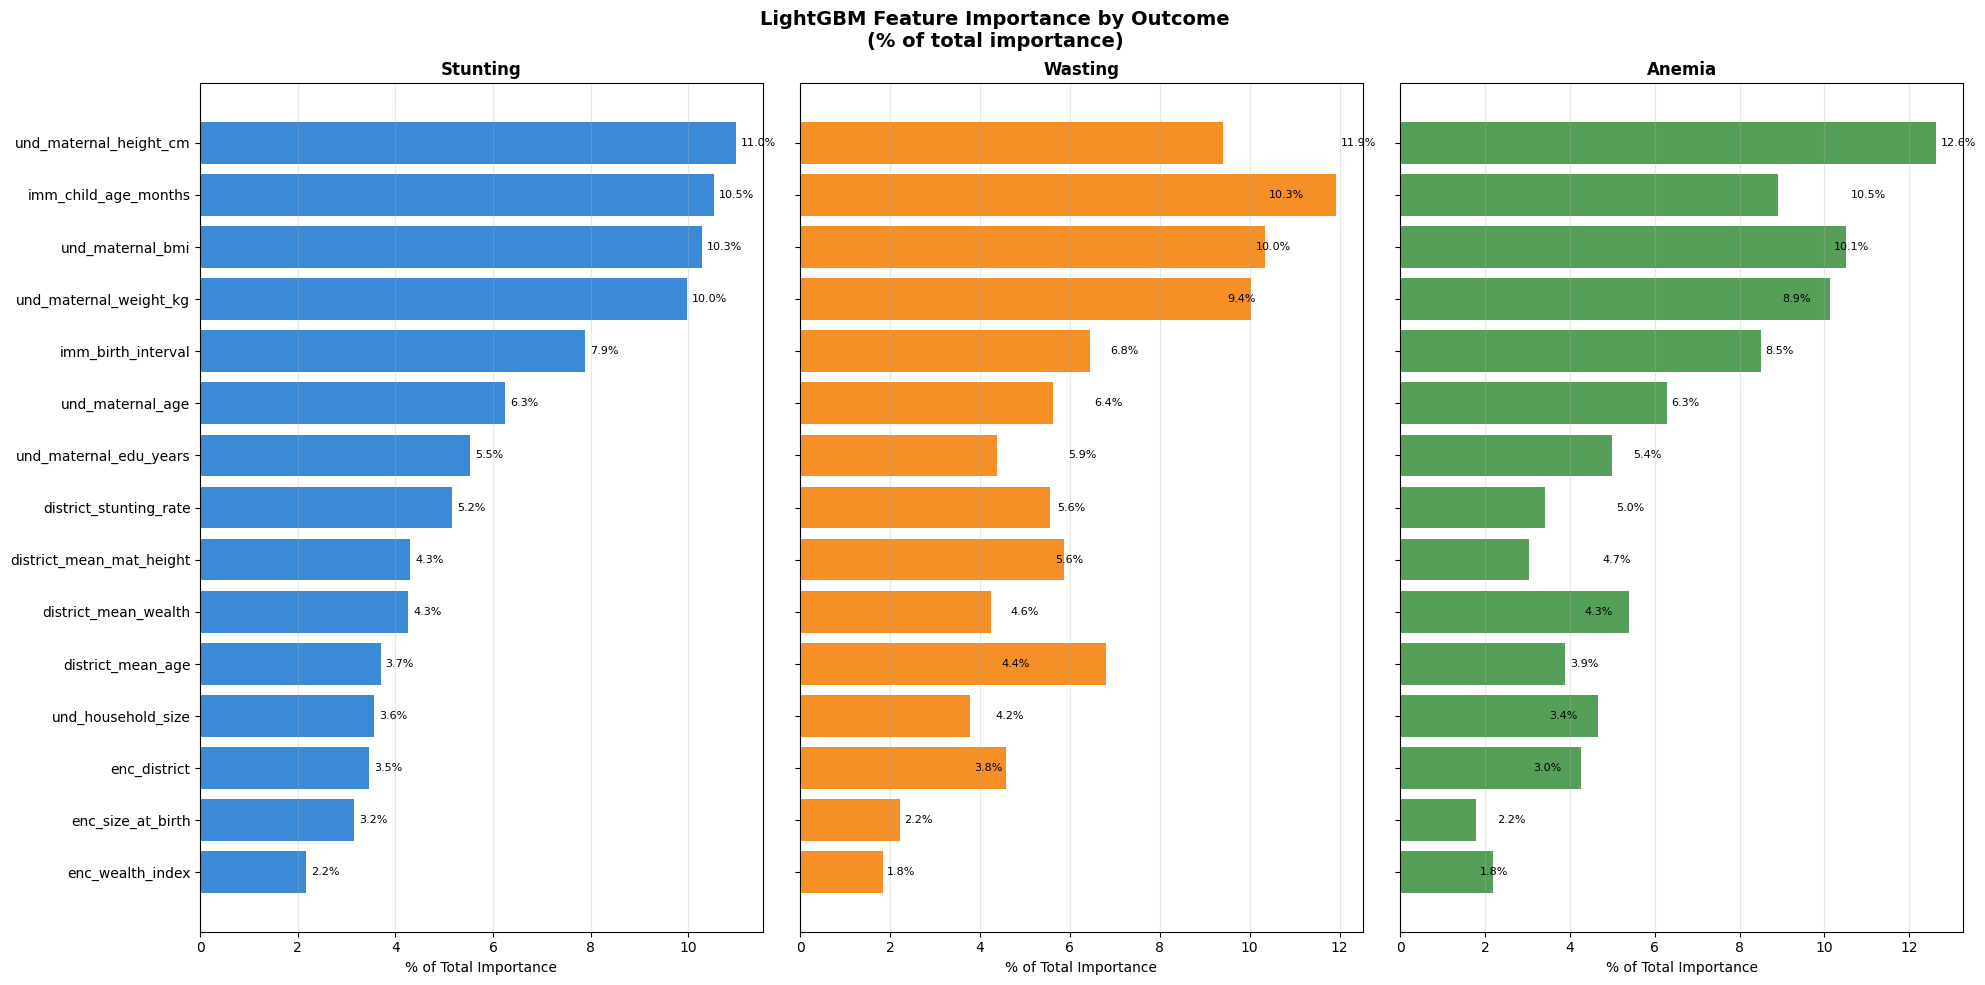

Saved: feature_importance_by_outcome.png


In [12]:
# retrain on full datasets for feature importance
print("Retraining final models on full datasets...")

lgb_w.fit(X_w, y_w, sample_weight=w_w)
lgb_a.fit(X_a, y_a, sample_weight=w_a)

imp_w = pd.DataFrame({
    "feature": FEATURES,
    "wasting": lgb_w.feature_importances_
})
imp_a = pd.DataFrame({
    "feature": FEATURES,
    "anemia" : lgb_a.feature_importances_
})

lgb_stunting = joblib.load(MODELS / "lgb_stunting_v2.pkl")
imp_s = pd.DataFrame({
    "feature" : FEATURES,
    "stunting": lgb_stunting.feature_importances_
})

imp_combined = (imp_s
                .merge(imp_w, on="feature")
                .merge(imp_a, on="feature"))

for col in ["stunting", "wasting", "anemia"]:
    imp_combined[col] = (imp_combined[col] /
                         imp_combined[col].sum() * 100)

imp_combined["mean_importance"] = imp_combined[
    ["stunting", "wasting", "anemia"]
].mean(axis=1)
imp_combined = imp_combined.sort_values("mean_importance", ascending=False)

print("\n=== Top 15 features by mean importance across outcomes ===")
print(imp_combined.head(15)[
    ["feature", "stunting", "wasting", "anemia", "mean_importance"]
].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
fig.suptitle("LightGBM Feature Importance by Outcome\n(% of total importance)",
             fontsize=14, fontweight="bold")

top15 = imp_combined.head(15)
outcome_colors = {
    "stunting": "#1976D2",
    "wasting" : "#F57C00",
    "anemia"  : "#388E3C"
}

for ax, outcome in zip(axes, ["stunting", "wasting", "anemia"]):
    data = top15.sort_values(outcome, ascending=True)
    ax.barh(data["feature"], data[outcome],
            color=outcome_colors[outcome], alpha=0.85)
    ax.set_xlabel("% of Total Importance", fontsize=10)
    ax.set_title(outcome.capitalize(), fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row[outcome] + 0.1, i,
                f"{row[outcome]:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "feature_importance_by_outcome.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: feature_importance_by_outcome.png")

## Saving models and results

In [13]:
# save all models
joblib.dump(lgb_w, MODELS / "lgb_wasting_v1.pkl")
joblib.dump(rf_w,  MODELS / "rf_wasting_v1.pkl")
joblib.dump(lgb_a, MODELS / "lgb_anemia_v1.pkl")
joblib.dump(rf_a,  MODELS / "rf_anemia_v1.pkl")

print("Models saved:")
for f in sorted(MODELS.glob("*_wasting_v1.pkl")) :
    print(f"  {f.name}")
for f in sorted(MODELS.glob("*_anemia_v1.pkl")):
    print(f"  {f.name}")

imp_combined.to_csv(
    PROJECT_ROOT / "outputs" / "feature_importance_all_outcomes.csv",
    index=False
)

print("\n=== FINAL RESULTS ===")
print("\nWasting:")
print(results_w_df.round(4))
print("\nAnemia:")
print(results_a_df.round(4))

print("\n=== Three-outcome summary ===")
summary = pd.DataFrame({
    "Stunting" : {"Best ROC-AUC": 0.6856, "Best F1": 0.5447,
                  "Prevalence": 0.358, "N": 5122},
    "Wasting"  : {"Best ROC-AUC": results_w_df["roc_auc"].max(),
                  "Best F1": results_w_df["f1"].max(),
                  "Prevalence": 0.021, "N": 5122},
    "Anemia"   : {"Best ROC-AUC": results_a_df["roc_auc"].max(),
                  "Best F1": results_a_df["f1"].max(),
                  "Prevalence": 0.489, "N": 3839}
})
print(summary.round(4))

Models saved:
  lgb_wasting_v1.pkl
  rf_wasting_v1.pkl
  lgb_anemia_v1.pkl
  rf_anemia_v1.pkl

=== FINAL RESULTS ===

Wasting:
                     pr_auc  roc_auc      f1  recall  precision
model                                                          
Logistic Regression  0.0499   0.5630  0.0506  0.3091     0.0276
Random Forest        0.0575   0.6089  0.0462  0.0273     0.1567
XGBoost              0.0654   0.6183  0.0759  0.3455     0.0426
LightGBM             0.0725   0.6146  0.0716  0.3364     0.0401

Anemia:
                     roc_auc      f1  recall  precision
model                                                  
Logistic Regression   0.6738  0.6089  0.5972     0.6213
Random Forest         0.6799  0.6090  0.5796     0.6416
XGBoost               0.6561  0.6028  0.5860     0.6210
LightGBM              0.6517  0.5895  0.5722     0.6081

=== Three-outcome summary ===
               Stunting    Wasting     Anemia
Best ROC-AUC     0.6856     0.6183     0.6799
Best F1          0.54

## Summary and Interpretation

Three outcomes, three very different modeling challenges, and the numbers reflect 
that clearly.

Anemia came out most predictable at ROC-AUC 0.6799 with Random Forest, almost 
identical to stunting. The near-balanced classes help but that is not the whole 
story. What surprised me in the feature importance plot was that maternal height 
still dominates at 12.6% for anemia. I went in expecting region and district to 
rank higher because malaria exposure is geographically concentrated in Malawi's 
southern and lakeshore districts, and malaria is a major driver of childhood 
anemia. They do rank slightly higher than in stunting but maternal anthropometry 
still leads. It seems that maternal nutritional status at the time of pregnancy 
leaves a mark on the child's iron stores and hemoglobin that persists long enough 
to show up in a cross-sectional survey months later.

Wasting was the hardest problem by far. PR-AUC of 0.0725 against a baseline of 
0.021 is real signal, about three and a half times a random classifier, but F1 
of 0.076 means the model cannot reliably pick out individual wasted children from 
the sample. With only 110 positive cases SMOTE and aggressive class weighting can 
only stretch the data so far. The ROC-AUC of 0.61 looks acceptable until you 
look at the PR curve and see how quickly precision collapses. The more fundamental 
problem is that the DHS design visits each household once. Wasting is an acute 
condition that can develop and resolve within weeks. A single visit captures a 
snapshot, and that snapshot may catch a child who was fine two weeks earlier and 
will be fine again in two weeks. You cannot build a reliable wasting classifier 
from that kind of data regardless of the algorithm. Longitudinal or more frequent 
measurement data would change the picture.

The three-panel feature importance comparison is the finding I find most useful 
for the thesis argument. The top four predictors are the same across all three 
outcomes: maternal height, child age, maternal BMI, and maternal weight. Together 
they account for roughly 40% of total importance in every model. That is not a 
coincidence. It is the upstream pathway showing up consistently regardless of 
which downstream outcome you are predicting. Whatever improves maternal nutritional 
status before and during pregnancy is going to move stunting, wasting, and anemia 
together, not just one at a time.

The outcomes start to diverge in the middle of the rankings. District mean age 
sits fourth for wasting at 6.8% but eleventh for stunting at 3.7%. Wasting 
responds to current food availability which varies by season and by where in a 
district you are. Stunting accumulates over months so it smooths over those 
short-term fluctuations. Birth interval ranks higher for anemia than wasting, 
which makes sense given what closely spaced pregnancies do to maternal iron stores 
and consequently to the iron the baby is born with.

The three-outcome summary puts it plainly. Stunting and anemia sit at the same 
predictability ceiling around 0.68 ROC-AUC using the same features and the same 
approach. Wasting sits lower and that gap is real and not fixable with a better 
algorithm. It is a data design problem.